In [ ]:
import pandas as pd 
from lets_plot import *
import sqlite3
import json
LetsPlot.setup_html()
import numpy as np 
import inspect
import plotly.express as px

In [5]:
conn = sqlite3.connect('../../data/main.db') 

fire_pokemon_sql_query = '''
SELECT *
  FROM fire_pokemon;
'''

ice_pokemon_sql_query = '''
SELECT * 
  FROM ice_pokemon;
'''

water_pokemon_sql_query = '''
SELECT * 
  FROM water_pokemon;
'''

fire_poke_df = pd.read_sql(fire_pokemon_sql_query, conn)
ice_pokemon_df = pd.read_sql(ice_pokemon_sql_query, conn)
water_poke_df = pd.read_sql(water_pokemon_sql_query, conn)

conn.close()


In [6]:
poke_df = pd.read_json('../../data/pokemon_data/main_pokemon_df.json')

In [10]:
custom_colors = {
    'grass': '#78C850',  # Green
    'fire': '#F08030',   # Red-Orange
    'water': '#6890F0',  # Blue
    'electric': '#F8D030',  # Yellow
    'ice': '#98D8D8',    # Light Blue
    'rock': '#B8A038',   # Brown
    'ground': '#E0C068', # Sandy Brown
    'steel': '#B8B8D0',  # Gray
    'fairy': '#EE99AC',  # Pink
    'ghost': '#705898',  # Purple
    'dragon': '#7038F8', # Deep Purple
    'dark': '#705848',   # Dark Gray
    'fighting': '#C03028',  # Red
    'psychic': '#F85888',  # Magenta
    'flying': '#A890F0',  # Light Blue
    'poison': '#A040A0',  # Purple
    'bug': '#A8B820',     # Olive Green
    'normal': '#A8A878',  # Neutral Beige
}

In [7]:
filtered_poke_df = poke_df[(poke_df['type_1'] == 'fire') | (poke_df['type_1'] == 'ice') | (poke_df['type_1'] == 'water')]
display(filtered_poke_df)

,name,url,generation,habitat_name,pokemon_description,type_1,type_2,pokemon_portrait,hp_stat,attack_stat,defense_stat,special_attack_stat,special_defense_stat,speed_stat,total_stat
4,charmander,https://pokeapi.co/api/v2/pokemon-species/4/,1,mountain,"Obviously prefers hot places. When it rains, s...",fire,None,https://raw.githubusercontent.com/PokeAPI/spri...,39,52,43,60,50,65,309
5,charmeleon,https://pokeapi.co/api/v2/pokemon-species/5/,1,mountain,"When it swings its burning tail, it elevates t...",fire,None,https://raw.githubusercontent.com/PokeAPI/spri...,58,64,58,80,65,80,405
6,charizard,https://pokeapi.co/api/v2/pokemon-species/6/,1,mountain,Spits fire that is hot enough to melt boulders...,fire,flying,https://raw.githubusercontent.com/PokeAPI/spri...,78,84,78,109,85,100,534
7,squirtle,https://pokeapi.co/api/v2/pokemon-species/7/,1,waters-edge,"After birth, its back swells and hardens into ...",water,None,https://raw.githubusercontent.com/PokeAPI/spri...,44,48,65,50,64,43,314
8,wartortle,https://pokeapi.co/api/v2/pokemon-species/8/,1,waters-edge,Often hides in water to stalk unwary prey. For...,water,None,https://raw.githubusercontent.com/PokeAPI/spri...,59,63,80,65,80,58,405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,dondozo,https://pokeapi.co/api/v2/pokemon-species/977/,9,None,"This Pokémon is a glutton, but it’s bad at get...",water,None,https://raw.githubusercontent.com/PokeAPI/spri...,150,100,115,65,65,35,530
991,iron-bundle,https://pokeapi.co/api/v2/pokemon-species/991/,9,None,Its shape is similar to a robot featured in a ...,ice,water,https://raw.githubusercontent.com/PokeAPI/spri...,56,80,114,124,60,136,570
994,iron-moth,https://pokeapi.co/api/v2/pokemon-species/994/,9,None,This Pokémon resembles an unknown object descr...,fire,poison,https://raw.githubusercontent.com/PokeAPI/spri...,80,70,60,140,110,110,570
1009,walking-wake,https://pokeapi.co/api/v2/pokemon-species/1009/,9,None,This ferocious creature is shrouded in mystery...,water,dragon,https://raw.githubusercontent.com/PokeAPI/spri...,99,83,91,125,83,109,590


In [20]:
main_ridge_plot = ggplot(poke_df, aes(x='total_stat', y='type_1', fill='type_1')) + \
       geom_area_ridges(scale=4, alpha=0.7, tooltips=layer_tooltips().title("@type_1").line("Total Stat|@total_stat")) + \
       scale_fill_manual(values = custom_colors) + \
       ggtitle('Correlation between Primary Type and Stat Total',) + \
       xlab('Stat Total') + \
       ylab('Pokemon Type') + \
       theme_minimal() + \
       ggsize(1000, 600) + \
       theme(axis_text_x=element_text(angle=45, hjust=1),
             plot_title=element_text(size=16, face='bold', hjust = 0.5),
             axis_title=element_text(size=12),
             legend_title=element_text(size=12),
             legend_text=element_text(size=10))

main_ridge_plot.show()
ggsave(main_ridge_plot, "../../../visuals/html_files/main_ridge_plot.html")

'c:\\Users\\chang\\DS105A\\ds105a-2024-project-error_105\\visuals\\html_files\\main_ridge_plot.html'

In [21]:
filtered_ridge_plot = ggplot(filtered_poke_df, aes(x='total_stat', y='type_1', fill='type_1')) + \
       geom_area_ridges(scale=4, alpha=0.7, tooltips=layer_tooltips().title("@type_1").line("Total Stat|@total_stat")) + \
       scale_fill_manual(values = custom_colors) + \
       ggtitle('Correlation between Primary Type and Stat Total',) + \
       xlab('Stat Total') + \
       ylab('Pokemon Type') + \
       theme_minimal() + \
       ggsize(1000, 600) + \
       theme(axis_text_x=element_text(angle=45, hjust=1),
             plot_title=element_text(size=16, face='bold', hjust = 0.5),
             axis_title=element_text(size=12),
             legend_title=element_text(size=12),
             legend_text=element_text(size=10))

filtered_ridge_plot.show()
ggsave(filtered_ridge_plot, "../../../visuals/html_files/filtered_ridge_plot.html")

'c:\\Users\\chang\\DS105A\\ds105a-2024-project-error_105\\visuals\\html_files\\filtered_ridge_plot.html'

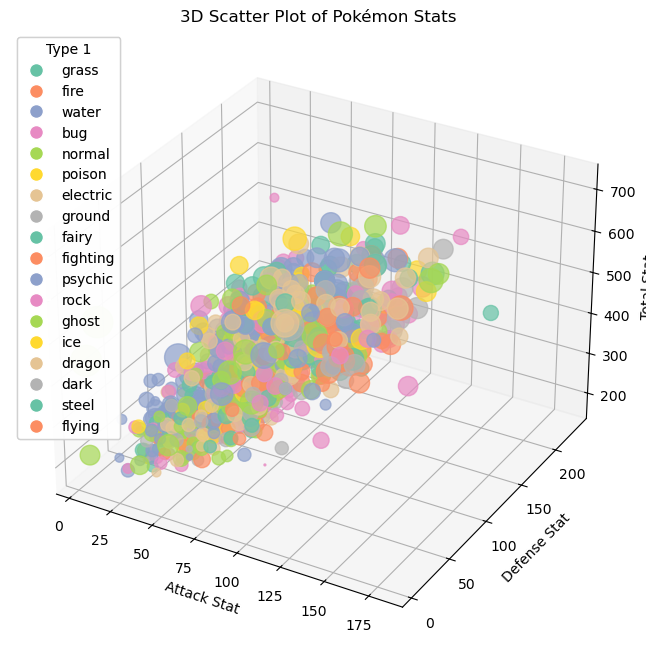

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


type_colors = sns.color_palette("Set2", n_colors=poke_df['type_1'].nunique())
color_map = {type_: color for type_, color in zip(poke_df['type_1'].unique(), type_colors)}
scatter = ax.scatter(poke_df['attack_stat'], poke_df['defense_stat'], poke_df['total_stat'], 
                     c=poke_df['type_1'].map(color_map), s=poke_df['hp_stat'] * 2, alpha=0.7)

# Labels and Title
ax.set_xlabel('Attack Stat')
ax.set_ylabel('Defense Stat')
ax.set_zlabel('Total Stat')
ax.set_title('3D Scatter Plot of Pokémon Stats')

# Add a legend for types
legend1 = ax.legend([plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
                     for color in color_map.values()],
                    poke_df['type_1'].unique(), title="Type 1", loc="upper left")
ax.add_artist(legend1)

# Show the plot
plt.show()

# Optional: Save the plot as an interactive Plotly plot
fig_plotly = px.scatter_3d(poke_df, x='attack_stat', y='defense_stat', z='total_stat', 
                           color='type_1', size='hp_stat', 
                           title="3D Scatter Plot of Pokémon Stats")
fig_plotly.show()


In [ ]:
poke_df = pd.read_json('../../data/pokemon_data/main_pokemon_df.json')

poke_df['habitat_name'] = poke_df['habitat_name'].fillna('None')

type_habitat_counts = poke_df.groupby(['type_1', 'habitat_name']).size().reset_index(name='count')

all_types = poke_df['type_1'].unique()
all_habitats = poke_df['habitat_name'].unique()

all_combinations = pd.MultiIndex.from_product([all_types, all_habitats], names=['type_1', 'habitat_name'])
type_habitat_counts = type_habitat_counts.set_index(['type_1', 'habitat_name']).reindex(all_combinations, fill_value=0).reset_index()
types_and_habitats_fig = px.scatter(type_habitat_counts, 
                 x='type_1', 
                 y='habitat_name', 
                 size='count',  
                 color='type_1', 
                 title="2D Scatter Plot of Pokémon Types vs. Habitats",
                 labels={'type_1': 'Pokémon Type', 'habitat_name': 'Habitat', 'count': 'Pokémon Count'},
                 color_discrete_sequence=px.colors.qualitative.Set3, 
                 opacity=0.7)

types_and_habitats_fig.show()
types_and_habitats_fig.write_html("../../visuals/html_files/pokemon_types_vs_habitats.html")

